## Downscaling and moving windows
- Downscaling DTM rasters to 30m to have same-level scale with LST images 
- computing moving windows and study the correlations with LST depending on the size of the window.

### Libraries and general paths

In [ ]:
!pip install rasterio
!pip install tqdm

In [1]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import ndimage
from rasterio import mask
import geopandas as gpd
from scipy.ndimage import convolve
from tqdm import tqdm  
from rasterio.crs import CRS
from rasterio.transform import Affine

In [2]:
lst_cropped_path = '../../../datos-notebooks/3.HR-data-bologna/base-data/LST/LST_cropped_celsius.tif' # values out of bound are 0
lst_clipped_path = '../../../datos-notebooks/3.HR-data-bologna/base-data/LST/LST_clipped_celsius.tif' #values out of bound are nan
dtm_path = '../../../datos-notebooks/3.HR-data-bologna/topography/dtm_mosaic.tif'

bound = "../../../datos-notebooks/3.HR-data-bologna/base-data/vectors/bologne_boundary.geojson"
gdf = gpd.read_file(bound)


In [14]:
def save_raster(filename, array, output_dir):
    profile = lst_profile.copy()
    profile.update(dtype=rasterio.float32, count=1, compress='lzw')
    with rasterio.open(os.path.join(output_dir, filename), 'w', **profile) as dst:
        dst.write(array.astype(np.float32), 1)

In [3]:
with rasterio.open(lst_cropped_path) as lst_ref:
    lst_profile = lst_ref.profile
    lst_transform = lst_ref.transform
    lst_crs = lst_ref.crs
    lst_shape = (lst_ref.height, lst_ref.width)
    
with rasterio.open(lst_clipped_path) as lst:
    lst_crs = lst.crs
    lst_clip = lst.read(1)          
    lst_transform = lst.transform 

In [4]:
output_dir = '../../../datos-notebooks/3.HR-data-bologna/topography/rasters_30m/'
os.makedirs(output_dir, exist_ok=True)
filled_rasters_dir = '../../../datos-notebooks/3.HR-data-bologna/topography/rasters_30m_filled/'
os.makedirs(filled_rasters_dir, exist_ok=True)
moving_windows_dir = '../../../datos-notebooks/3.HR-data-bologna/topography/moving_windows/'
os.makedirs(moving_windows_dir, exist_ok=True)

### Computing derived variables and downscaling to 30m aligned with LST raster

In [ ]:
# compute DTM-based variables at full resolution (0.5m) and then resample (average) to 30m

with rasterio.open(dtm_path) as dtm_src:
    dtm_data = dtm_src.read(1)
    dtm_profile = dtm_src.profile
    nodata_val = dtm_src.nodata

    # Force CRS if missing
    if dtm_src.crs is None:
        dtm_crs = CRS.from_epsg(7791)
    else:
        dtm_crs = dtm_src.crs

    # Mask nodata values
    if nodata_val is not None:
        dtm_masked = np.where(dtm_data == nodata_val, np.nan, dtm_data).astype(np.float32)
    else:
        dtm_masked = dtm_data.astype(np.float32)
    del dtm_data  # free RAM

    # Pixel size at full resolution (0.5m)
    xres_hr = dtm_src.transform.a
    yres_hr = -dtm_src.transform.e

    # Compute gradients at full resolution
    dz_dy, dz_dx = np.gradient(dtm_masked, yres_hr, xres_hr)

    # Remove padding
    dz_dy = dz_dy[1:-1, 1:-1]
    dz_dx = dz_dx[1:-1, 1:-1]
    dtm_trimmed = dtm_masked[1:-1, 1:-1]
    del dtm_masked  # free RAM

    # Adjust transform for trimmed array (1 pixel offset)
    trimmed_transform = Affine(
        dtm_src.transform.a,
        dtm_src.transform.b,
        dtm_src.transform.c + dtm_src.transform.a,
        dtm_src.transform.d,
        dtm_src.transform.e,
        dtm_src.transform.f + dtm_src.transform.e
    )

    # --- Elevation ---
    out = np.empty(lst_shape, dtype=np.float32)
    reproject(
        source=dtm_trimmed,
        destination=out,
        src_transform=trimmed_transform,
        src_crs=dtm_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )
    save_raster('elev_mean.tif', out, output_dir)
    del out
    print("elev_mean.tif saved")

    # --- Slope ---
    slope_hr = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    out = np.empty(lst_shape, dtype=np.float32)
    reproject(
        source=np.degrees(slope_hr),
        destination=out,
        src_transform=trimmed_transform,
        src_crs=dtm_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )
    save_raster('slope_mean.tif', out, output_dir)
    del slope_hr, out
    print("slope_mean.tif saved")

    # --- Aspect (base for northness and eastness) ---
    aspect_hr = np.arctan2(dz_dx, -dz_dy)
    aspect_hr = np.where(aspect_hr < 0, 2 * np.pi + aspect_hr, aspect_hr)
    del dz_dx, dz_dy  # no longer needed

    # --- Northness ---
    out = np.empty(lst_shape, dtype=np.float32)
    reproject(
        source=np.cos(aspect_hr),
        destination=out,
        src_transform=trimmed_transform,
        src_crs=dtm_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )
    save_raster('northness.tif', out, output_dir)
    del out
    print("northness.tif saved")

    # --- Eastness ---
    out = np.empty(lst_shape, dtype=np.float32)
    reproject(
        source=np.sin(aspect_hr),
        destination=out,
        src_transform=trimmed_transform,
        src_crs=dtm_crs,
        dst_transform=lst_transform,
        dst_crs=lst_crs,
        resampling=Resampling.average
    )
    save_raster('eastness.tif', out, output_dir)
    del aspect_hr, out
    print("eastness.tif saved")

print("Finished. Files saved as elev_mean.tif, slope_mean.tif, northness.tif, eastness.tif")

In [ ]:
var_path = os.path.join(output_dir, "elev_mean.tif")

with rasterio.open(var_path) as src_var:
    var_data = src_var.read(1).astype(float)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(var_data, cmap='terrain')
ax.set_title("Elevación media (m)", fontsize=12)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

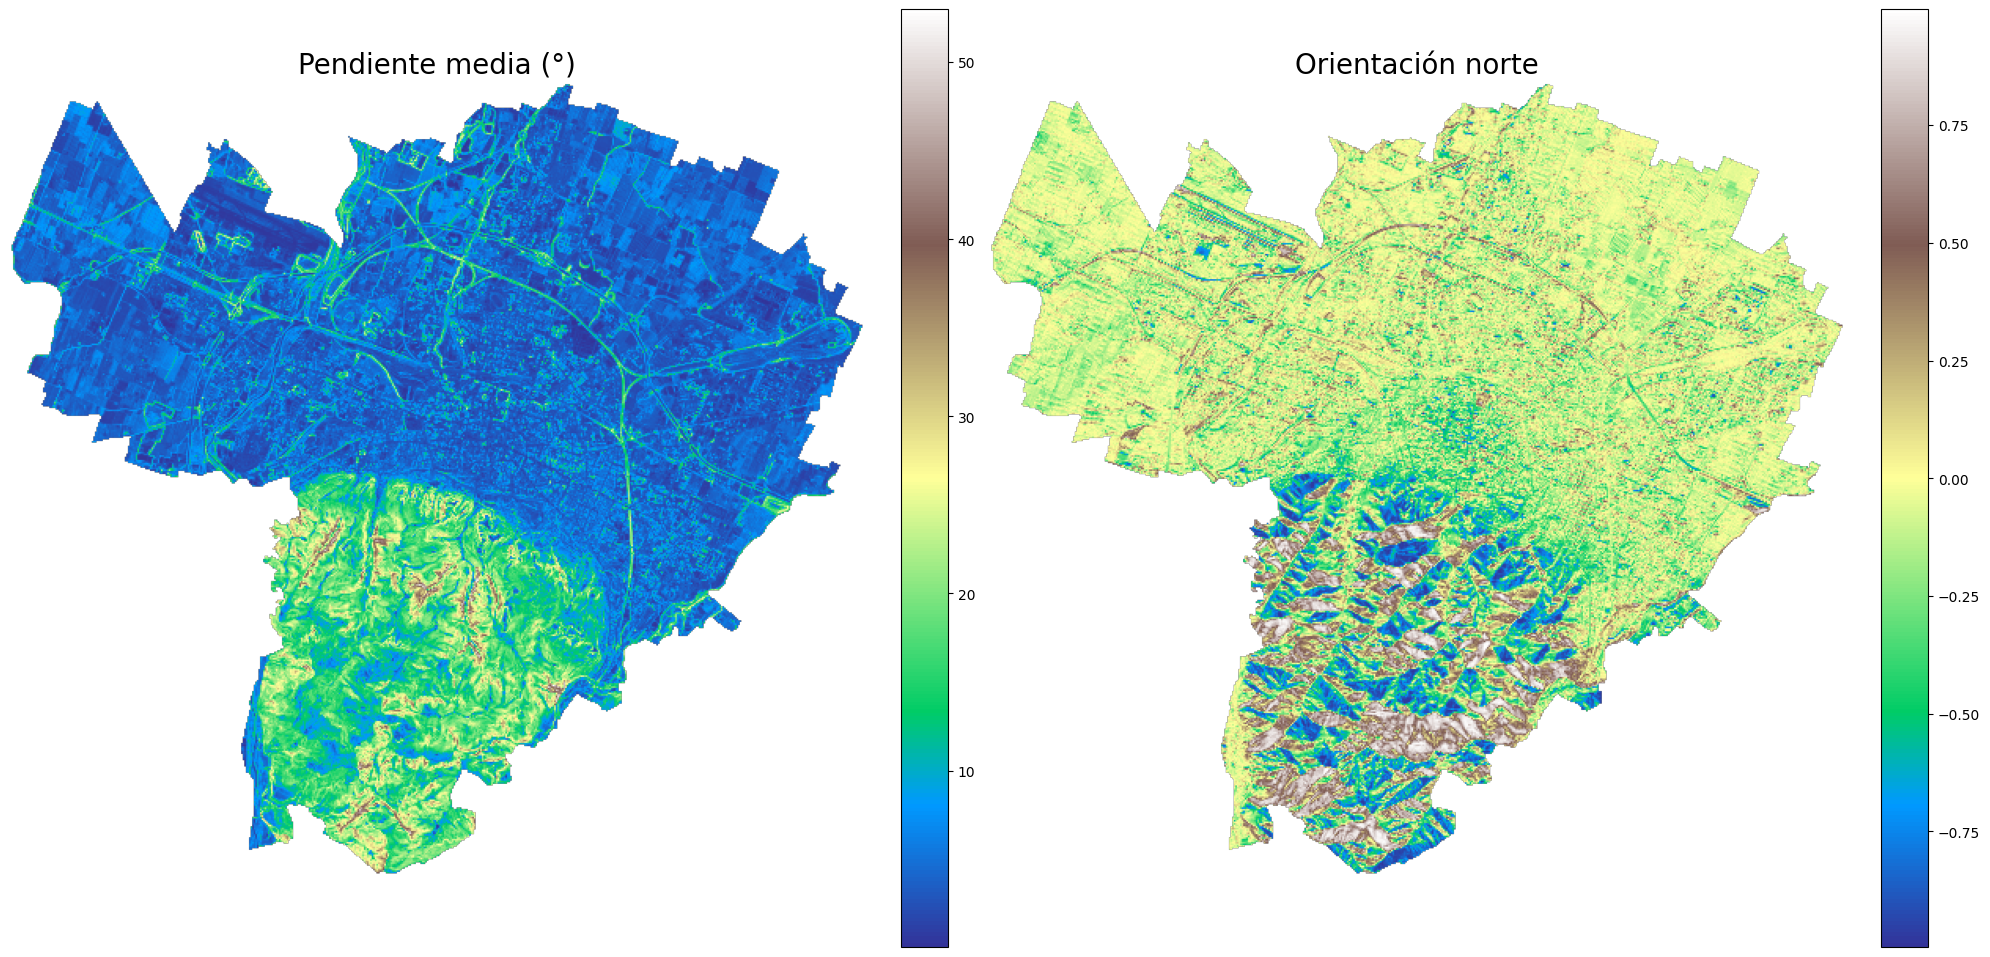

In [7]:
variables = {
    "slope_mean.tif": "Pendiente media (°)",
    "northness.tif":  "Orientación norte",
}

fig, axes = plt.subplots(1, 2, figsize=(20, 20))
axes = axes.flatten()

for ax, (var_name, titulo) in zip(axes, variables.items()):
    with rasterio.open(os.path.join(output_dir, var_name)) as src:
        var_data = src.read(1).astype(float)

    im = ax.imshow(var_data, cmap='terrain')
    ax.set_title(titulo, fontsize=20)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()

### fill nodata values to avoid issues with moving windows

In [ ]:
def fill_nan_nearest(array):
    """Fill NaN values with nearest valid neighbor."""
    mask = np.isnan(array)
    if np.any(mask):
        indices = ndimage.distance_transform_edt(
            mask,
            return_distances=False,
            return_indices=True
        )
        filled = array.copy()
        filled[mask] = array[tuple(indices[:, mask])]
        return filled
    else:
        return array

In [ ]:
# Open the rasters
with rasterio.open(os.path.join(output_dir, 'elev_mean.tif')) as src:
    dtm_resampled = src.read(1).astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        dtm_resampled = np.where(dtm_resampled == nodata, np.nan, dtm_resampled)

with rasterio.open(os.path.join(output_dir, 'slope_mean.tif')) as src:
    slope_deg = src.read(1).astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        slope_deg = np.where(slope_deg == nodata, np.nan, slope_deg)
    slope = np.radians(slope_deg)  # convert to radians if the second block uses np.degrees(slope)
    del slope_deg

with rasterio.open(os.path.join(output_dir, 'northness.tif')) as src:
    northness = src.read(1).astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        northness = np.where(northness == nodata, np.nan, northness)

with rasterio.open(os.path.join(output_dir, 'eastness.tif')) as src:
    eastness = src.read(1).astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        eastness = np.where(eastness == nodata, np.nan, eastness)

In [ ]:
# List of rasters and names
rasters = [
    ("elev_mean.tif", dtm_resampled),
    ("slope_mean.tif", np.degrees(slope)),
    ("northness.tif", northness),
    ("eastness.tif", eastness),
]

for i, (name, array) in enumerate(rasters):
    if i < 2:
        # Fill with nearest neighbor only for elevation and slope
        array_filled = fill_nan_nearest(array)
    else:
        # Replace NaN with 0 for northness and eastness
        array_filled = np.where(np.isnan(array), 0, array)
    
    save_raster(name, array_filled, filled_rasters_dir)

print("Finished. Rasters filled.")

### Moving windows

In [17]:
files = {
    "elev_mean": os.path.join(filled_rasters_dir, "elev_mean.tif"),
    "slope_mean": os.path.join(filled_rasters_dir, "slope_mean.tif"),
    "northness": os.path.join(filled_rasters_dir, "northness.tif"),
    "eastness": os.path.join(filled_rasters_dir, "eastness.tif"),
} 


In [18]:
def distance_weighted_kernel(size):
    """Create a distance-weighted Gaussian kernel."""
    assert size % 2 == 1 #Size must be odd
    center = size // 2
    y, x = np.ogrid[:size, :size]
    distance = np.sqrt((x - center)**2 + (y - center)**2)
    sigma = size / 4
    weights = np.exp(-(distance**2) / (2 * sigma**2))
    weights /= weights.sum()  # normalize
    return weights

def moving_window_weighted(array, kernel):
    """Apply convolution with given kernel."""
    return convolve(array, kernel, mode='nearest')


In [ ]:
# visualyze weighted kernel
k = distance_weighted_kernel(11)

plt.imshow(k, cmap='viridis')
plt.colorbar(label="Weight")
plt.title("Distance-weighted Gaussian kernel (11x11)")
plt.show()

In [ ]:
# visualyze weight profile
plt.plot(k[k.shape[0]//2], label="Center row")
plt.plot(k[:, k.shape[1]//2], label="Center column")
plt.legend()
plt.title("Weights decay from center")
plt.show()

In [20]:
max_window = 201

for var_name, path in tqdm(files.items(), desc="Variables"):  # Outer progress
    var_dir = os.path.join(moving_windows_dir, var_name)
    os.makedirs(var_dir, exist_ok=True)

    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)

    for w in tqdm(range(1, max_window+1, 2), desc=f"Windows {var_name}", leave=False):
        kernel = distance_weighted_kernel(w)
        avg_window = moving_window_weighted(data, kernel)

        out_name = f"{var_name}_win{w}.tif"
        save_raster(out_name, avg_window, var_dir)

print("Finished. All variables saved with distance-weighted moving windows.")


Variables: 100%|██████████| 4/4 [32:11<00:00, 482.88s/it]

Finished. All variables saved with distance-weighted moving windows.


In [ ]:
# Plots
window_sizes = range(1, 21,2)  
variables = ["elev_mean", "slope_mean", "northness", "eastness"]

for var_name in variables:
    var_folder = os.path.join(moving_windows_dir, var_name)
 
    # Create subplot grid
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()

    for idx, w in enumerate(window_sizes):
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        # Plot
        im = axes[idx].imshow(var_data, cmap='terrain' if 'elev' in var_name else 'RdYlBu_r')
        axes[idx].set_title(f"Win {w}")
        axes[idx].axis('off')
        plt.colorbar(im, ax=axes[idx], fraction=0.046, pad=0.04)

    plt.suptitle(f"{var_name} - Windows 1 to 10", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### correlations with LST

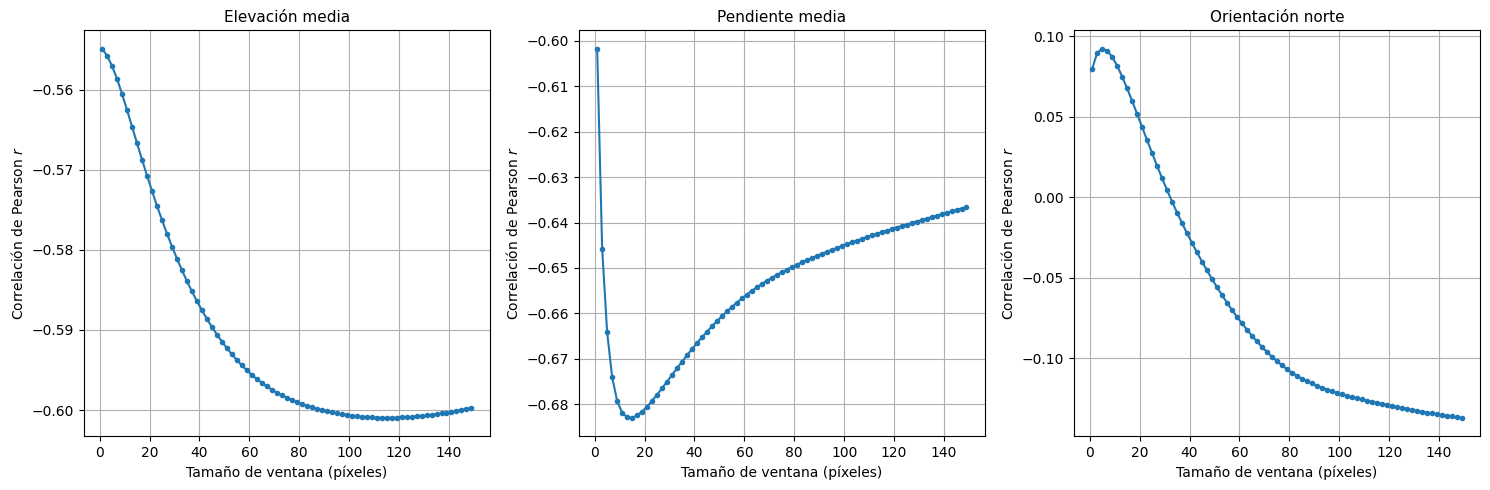

In [6]:
window_sizes = range(1, 151, 2)

variables = {
    "elev_mean": "Elevación media",
    "slope_mean": "Pendiente media",
    "northness": "Orientación norte",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, (var_name, label) in zip(axes, variables.items()):
    var_folder = os.path.join(moving_windows_dir, var_name)
    correlations = []

    for w in window_sizes:
        raster_path = os.path.join(var_folder, f"{var_name}_win{w}.tif")
        with rasterio.open(raster_path) as src_var:
            var_data = src_var.read(1).astype(float)

        valid = ~np.isnan(lst_clip)
        corr = np.corrcoef(var_data[valid], lst_clip[valid])[0, 1]
        correlations.append(corr)

    ax.plot(window_sizes, correlations, marker='o', markersize=3)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Tamaño de ventana (píxeles)")
    ax.set_ylabel("Correlación de Pearson $r$")
    ax.grid(True)


plt.tight_layout()
plt.show()
